## 对比损失

In [1]:
import torch
from torch.nn import TripletMarginLoss # 三元组损失函数（对比损失）
from torch.nn.modules.loss import CrossEntropyLoss

In [2]:
loss_fn = TripletMarginLoss(margin=1.0, p=2)

In [3]:
a = torch.randn(100, 5)
p = torch.randn(100, 5)
n = torch.randn(100, 5)

In [5]:
loss = loss_fn(a, p, n)
print(loss)

tensor(1.1369)


## 椒盐噪声

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # 加载图像处理库
import torchvision.transforms as T # 图像转换

In [23]:
# 定义函数：给图像添加椒盐噪声
def pepper_salt(image, percentage):
    noise_image = image.copy()
    # 计算噪声点的个数
    noise_num = int(image.shape[0] * image.shape[1] * percentage) # H * W * percentage
    # 遍历所有噪声点，随机生成
    for i in range(noise_num):
        # 随机生成坐标
        randx = np.random.randint(noise_image.shape[0])
        randy = np.random.randint(noise_image.shape[1])
        # 随机判断黑白
        if np.random.rand() < 0.5:
            noise_image[randx, randy] = 0
        else:
            noise_image[randx, randy] = 1
    return noise_image

In [10]:
# 测试
# 1. 加载原始图片
image = Image.open('Apple.jpg')
print(image)

<PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=600x574 at 0x134A42270>


In [13]:
# 定义图像转换操作*（调整大小，转为Tensor）
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])
# 2. 转换图片
img_tensor = transform(image)
print(img_tensor.shape)

torch.Size([3, 256, 256])


In [14]:
# 3. 转换为ndarray，方便画图
img_numpy = img_tensor.permute(1, 2, 0).numpy() # permute(1, 2, 0) 是为了将通道维度放到最后，符合matplotlib的要求
print(img_numpy.shape)

(256, 256, 3)


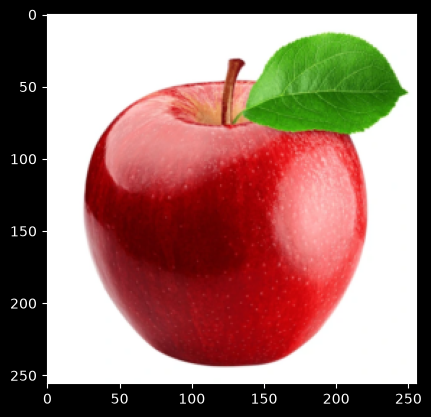

In [17]:
#  画图
plt.imshow(img_numpy)
plt.show()

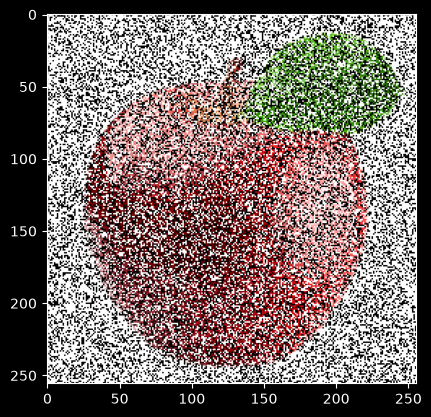

In [24]:
# 4. 加入椒盐噪声
noise_img = pepper_salt(img_numpy, 1)
plt.imshow(noise_img)
plt.show()

## 感知损失

In [25]:
import torchvision.models as models

In [27]:
from torchvision.models import VGG16_Weights

vgg = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

In [28]:
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
loss_net = torch.nn.Sequential(*list(vgg.features.children())[:10]) # 取前9层作为特征提取网络